# VedaVision — Chapter 7 Evaluation (real models, real data)

Loads your **actual trained models** (`processed/models/*.pkl`) and
**actual feature CSVs** (`processed/features/*.csv`), reusing the exact
functions `model_training.py`/`train_stage1_binary.py`/
`train_health_index.py` use internally (feature alignment, species
baselines, decision thresholds) — nothing here recomputes metrics with
a parallel, possibly-inconsistent implementation.

Run this from `module_3/notebooks/` (same convention as the single-leaf
pipeline notebook) after you've trained/saved the models this reads.

Figures save to `figures_out/` as 300dpi PNGs.


In [1]:
# MUST be set before the very first `import tensorflow` anywhere in this
# kernel session, or it has no effect (confirmed from VedaVision_DL_Benchmark.ipynb
# cell 1 -- TF >=2.16 defaults to Keras 3, which cannot deserialize a model saved
# under the older tf_keras/Keras-2 engine your DL benchmark notebook used).
# One-time setup in your venv if not already done: pip install tf-keras
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import os, sys
if not os.path.isdir("preprocessing"):
    os.chdir("..")
assert os.path.isdir("preprocessing") and os.path.isdir("models"), (
    f"Not at module_3/ root (cwd={os.getcwd()})."
)
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import joblib
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score,
)

FIG_DIR = Path("figures_out")
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, dpi=300):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[saved] {path}")

def plot_confusion_heatmap(cm_matrix, labels, title, save_as, normalise=False, cmap="Blues"):
    mat = cm_matrix.astype(float)
    if normalise:
        row_sums = mat.sum(axis=1, keepdims=True)
        mat = np.divide(mat, row_sums, out=np.zeros_like(mat), where=row_sums != 0)
    n = len(labels)
    fig, ax = plt.subplots(figsize=(max(8, n*0.7), max(7, n*0.65)))
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    thresh = mat.max() / 2.0
    for i in range(n):
        for j in range(n):
            val = cm_matrix[i, j]
            text = f"{val:.2f}" if normalise else f"{int(val)}"
            colour = "white" if mat[i, j] > thresh else "black"
            ax.text(j, i, text, ha="center", va="center", color=colour, fontsize=8,
                     weight="bold" if i == j else "normal")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    save_fig(fig, save_as)
    plt.show()


---
# 7.2 Species Identification

Loads the saved ensemble bundle (`vedavision_species_model.pkl`) and evaluates it on the sealed test CSV — the same evaluation `model_training.py --test` runs, done here so we keep the arrays for plotting.

In [2]:
SPECIES_MODEL_PATH = "processed/models/vedavision_species_model.pkl"     # <-- EDIT if your run used a different --out
SPECIES_TEST_CLF_CSV = "processed/features/vedavision_features_test_clf.csv"
SPECIES_TEST_FULL_CSV = "processed/features/vedavision_features_test.csv"   # has image_path, for item 5

bundle = joblib.load(SPECIES_MODEL_PATH)
model = bundle["model"]                      # fitted VotingClassifier (or wrapper w/ .base_model)
feat_cols = bundle["feature_columns"]         # exact column order used at training time
train_image_paths = bundle["train_image_paths"]

test_clf = pd.read_csv(SPECIES_TEST_CLF_CSV)
missing = set(feat_cols) - set(test_clf.columns)
assert not missing, f"Test CSV missing columns the model was trained on: {missing}"

X_test = test_clf[feat_cols].values
y_test = test_clf["species"].values
species_names = sorted(y_test.tolist().__class__(set(y_test)))  # sorted unique species, consistent axis order

y_pred = model.predict(X_test)

# Leakage sanity check the codebase itself flags as important (evaluate.py's job, reproduced here)
if "image_path" in test_clf.columns:
    leaked = set(test_clf["image_path"]) & train_image_paths
    print(f"[leakage check] {len(leaked)} test image_paths also seen in training "
          f"({'OK, none' if not leaked else 'WARNING — see below'})")

print(f"Test accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Test F1-macro:  {f1_score(y_test, y_pred, average='macro'):.4f}")
print(classification_report(y_test, y_pred))


Test accuracy:  0.9500
Test F1-macro:  0.9499
                   precision    recall  f1-score   support

             beli       1.00      1.00      1.00        20
          kalawal       0.85      0.85      0.85        20
    kasthuri_dehi       1.00      1.00      1.00        20
      kathurupila       0.95      1.00      0.98        20
    kattakumanjal       0.86      0.90      0.88        20
maha_undupiyaliya       0.94      0.85      0.89        20
      nil_awariya       1.00      0.90      0.95        20
         ranawara       1.00      1.00      1.00        20
         siymbala       1.00      1.00      1.00        20
 thunpath_kurundu       0.95      1.00      0.98        20
        wal_bilin       0.90      0.95      0.93        20
        wal_kollu       0.95      0.95      0.95        20

         accuracy                           0.95       240
        macro avg       0.95      0.95      0.95       240
     weighted avg       0.95      0.95      0.95       240



## 1. Confusion matrix heatmap (12×12)

[saved] figures_out\01_species_confusion_matrix.png


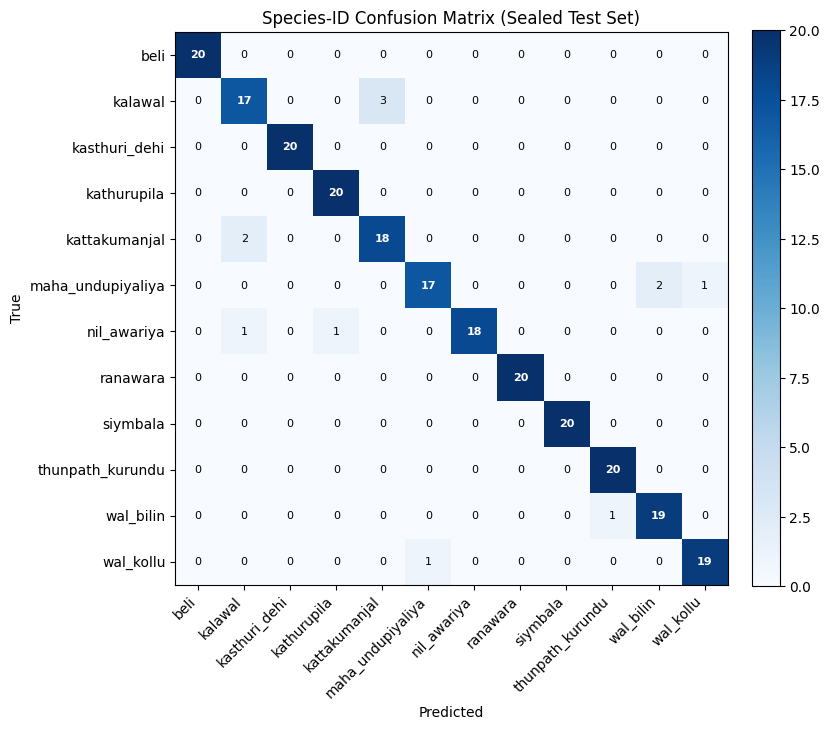

In [3]:
cm_matrix = confusion_matrix(y_test, y_pred, labels=species_names)
plot_confusion_heatmap(cm_matrix, species_names,
                        "Species-ID Confusion Matrix (Sealed Test Set)",
                        "01_species_confusion_matrix")


## 2. Base-learner comparison (RF / SVM / HGB / Ensemble)

Extracts each sub-estimator from the SAME fitted `VotingClassifier` and
evaluates it individually on the same test set. **Important gotcha
confirmed directly from `classifier.py`:** `VotingClassifier.fit()`
internally label-encodes `y`, so each sub-estimator's raw `.predict()`
returns integer class indices, not species strings — must decode via
`model.le_.inverse_transform(...)` or every comparison silently
evaluates against the wrong label space.

  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
[saved] figures_out\02_base_learner_comparison_cv.png


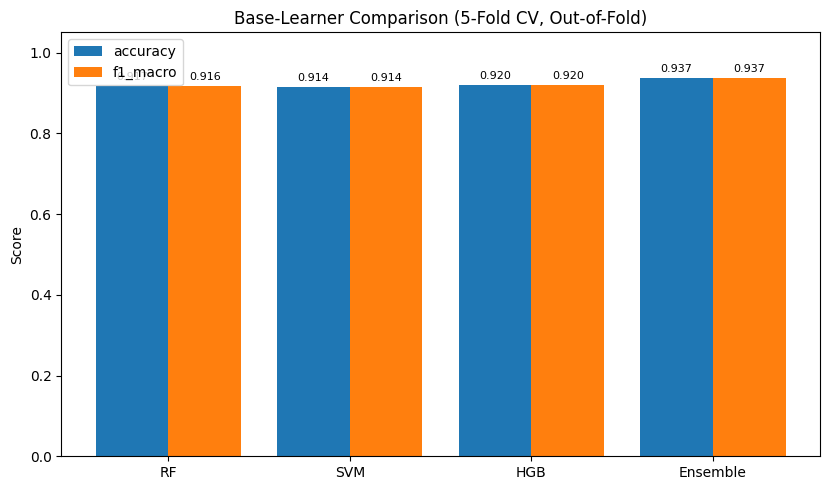

{'RF': {'accuracy': 0.9165942658557776, 'f1_macro': 0.9163816898231548}, 'SVM': {'accuracy': 0.9142360680153904, 'f1_macro': 0.914134599624416}, 'HGB': {'accuracy': 0.9203177361300733, 'f1_macro': 0.920131351874042}, 'Ensemble': {'accuracy': 0.9371974680402135, 'f1_macro': 0.937061570065314}}


In [8]:
from sklearn.model_selection import StratifiedGroupKFold
from models.species_id.classifier import make_species_classifier

SPECIES_TRAIN_CLF_CSV = "processed/features/vedavision_features_train_clf.csv"  # <-- EDIT if needed
train_clf = pd.read_csv(SPECIES_TRAIN_CLF_CSV)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_grouped_bar(data_dict, metrics, title, save_as, ylim=(0,1.05)):
    categories = list(data_dict.keys())
    n_metrics = len(metrics)
    x = np.arange(len(categories)); width = 0.8 / n_metrics
    fig, ax = plt.subplots(figsize=(1.6*len(categories)+2, 5))
    for i, metric in enumerate(metrics):
        vals = [data_dict[c][metric] for c in categories]
        bars = ax.bar(x + i*width - (n_metrics-1)*width/2, vals, width, label=metric)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(categories)
    ax.set_ylabel("Score"); ax.set_ylim(*ylim)
    ax.set_title(title); ax.legend()
    fig.tight_layout()
    save_fig(fig, save_as)
    plt.show()
    
X_train = train_clf[feat_cols].values
y_train = train_clf["species"].values
# Uses the TRAIN CSV (out-of-fold CV predictions), not the sealed test set —
# this matches how the ensemble-vs-single-learner decision was actually made.
assert "image_path" in train_clf.columns, (
    "train_clf CSV needs image_path for StratifiedGroupKFold grouping — "
    "check you loaded vedavision_features_train_clf.csv, not the test one."
)
groups_cv = train_clf["image_path"].values

N_SPLITS = 5  # <-- EDIT if your original CV used a different value
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)  # <-- EDIT random_state to match your original run

oof_pred = {"rf": [], "svm": [], "hgb": [], "ensemble": []}
oof_true = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train, groups_cv), 1):
    fold_model = make_species_classifier(random_state=42, feature_names=feat_cols)
    fold_model.fit(X_train[tr_idx], y_train[tr_idx])

    for name in ("rf", "svm", "hgb"):
        raw_pred = fold_model.named_estimators_[name].predict(X_train[va_idx])
        oof_pred[name].extend(fold_model.le_.inverse_transform(raw_pred))
    oof_pred["ensemble"].extend(fold_model.predict(X_train[va_idx]))
    oof_true.extend(y_train[va_idx])

    print(f"  fold {fold}/{N_SPLITS} done")

oof_true = np.array(oof_true)

cv_base_learner_scores = {}
for name, label in [("rf","RF"), ("svm","SVM"), ("hgb","HGB"), ("ensemble","Ensemble")]:
    preds = np.array(oof_pred[name])
    cv_base_learner_scores[label] = {
        "accuracy": accuracy_score(oof_true, preds),
        "f1_macro": f1_score(oof_true, preds, average="macro"),
    }

plot_grouped_bar(cv_base_learner_scores, ["accuracy", "f1_macro"],
                  "Base-Learner Comparison (5-Fold CV, Out-of-Fold)",
                  "02_base_learner_comparison_cv")
print(cv_base_learner_scores)

## 3. Per-species F1 bar chart, sorted, look-alike pairs colour-coded

[saved] figures_out\03_per_species_f1.png


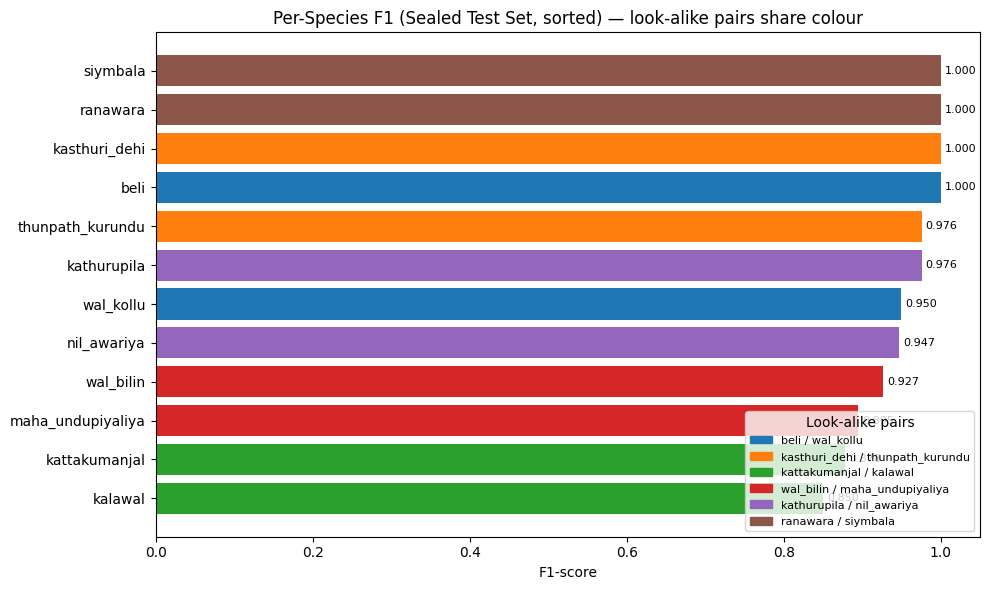

In [9]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
species_f1 = {s: report_dict[s]["f1-score"] for s in species_names if s in report_dict}

lookalike_pairs = [
    ("beli", "wal_kollu"),
    ("kasthuri_dehi", "thunpath_kurundu"),
    ("kattakumanjal", "kalawal"),
    ("wal_bilin", "maha_undupiyaliya"),
    ("kathurupila", "nil_awariya"),
    ("ranawara", "siymbala"),
]  # <-- EDIT if your species-name spelling in the CSV differs from this

def plot_species_f1(species_f1, lookalike_pairs, save_as):
    sorted_species = sorted(species_f1, key=species_f1.get)
    values = [species_f1[s] for s in sorted_species]
    pair_colors = plt.cm.tab10.colors
    species_to_colour = {}
    for i, (a, b) in enumerate(lookalike_pairs):
        species_to_colour[a] = pair_colors[i % len(pair_colors)]
        species_to_colour[b] = pair_colors[i % len(pair_colors)]
    colors = [species_to_colour.get(s, "lightgray") for s in sorted_species]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(sorted_species, values, color=colors)
    for b, v in zip(bars, values):
        ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center", fontsize=8)
    ax.set_xlabel("F1-score"); ax.set_xlim(0, 1.05)
    ax.set_title("Per-Species F1 (Sealed Test Set, sorted) — look-alike pairs share colour")
    handles = [plt.Rectangle((0,0),1,1, color=pair_colors[i % len(pair_colors)]) for i in range(len(lookalike_pairs))]
    labels = [f"{a} / {b}" for a, b in lookalike_pairs]
    ax.legend(handles, labels, loc="lower right", fontsize=8, title="Look-alike pairs")
    fig.tight_layout()
    save_fig(fig, save_as)
    plt.show()

plot_species_f1(species_f1, lookalike_pairs, "03_per_species_f1")


## 4. Hyperparameter tuning delta (tuned vs. untuned)

The saved model bundle only contains the **final tuned** ensemble — there's
no separate saved "untuned" model file. This cell retrains a fresh
ensemble using the documented pre-tuning defaults (from `classifier.py`'s
`make_species_classifier` docstring: RF `n_estimators=200` with no other
overrides, SVM `C=10, gamma='scale'`, HGB `max_iter=150` with no other
overrides) on the same train CSV, then compares both on the same test
set. This retrains once — expect it to take a similar amount of time to
the original training run.

[saved] figures_out\04_hyperparameter_tuning_delta.png


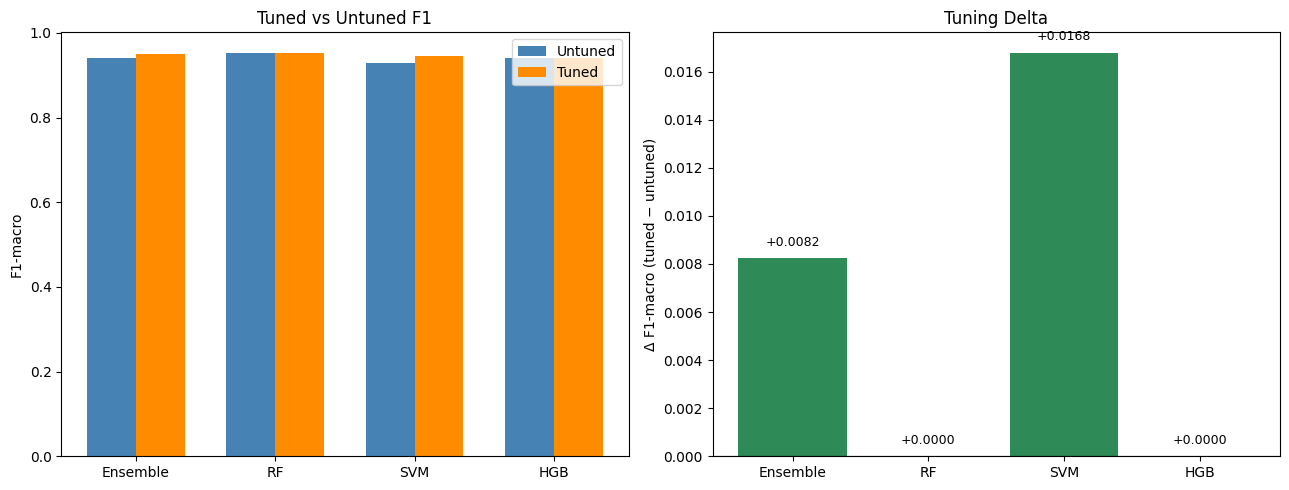

{'Ensemble': {'untuned_f1': 0.9416159222320967, 'tuned_f1': 0.9498502353444587}, 'RF': {'untuned_f1': 0.9538584176089026, 'tuned_f1': 0.9538584176089026}, 'SVM': {'untuned_f1': 0.9284419038236543, 'tuned_f1': 0.9452353586499926}, 'HGB': {'untuned_f1': 0.9419044601810969, 'tuned_f1': 0.9419044601810969}}


In [12]:
from models.species_id.classifier import make_species_classifier

SPECIES_TRAIN_CLF_CSV = "processed/features/vedavision_features_train_clf.csv"  # <-- EDIT if needed
train_clf = pd.read_csv(SPECIES_TRAIN_CLF_CSV)
X_train = train_clf[feat_cols].values
y_train = train_clf["species"].values

untuned_model = make_species_classifier(
    random_state=42, feature_names=feat_cols,
    rf_params={"n_estimators": 200},                    # pre-tuning defaults, per classifier.py docstring
    svm_params={"C": 10, "gamma": "scale"},
    hgb_params={"max_iter": 150},
)
untuned_model.fit(X_train, y_train)
y_pred_untuned = untuned_model.predict(X_test)

tuning_results = {
    "Ensemble": {
        "untuned_f1": f1_score(y_test, y_pred_untuned, average="macro"),
        "tuned_f1": f1_score(y_test, y_pred, average="macro"),
    }
}
# Per-base-learner tuned-vs-untuned, reusing the same decode step as item 2
untuned_voting = getattr(untuned_model, "base_model", untuned_model)
tuned_voting = getattr(model, "base_model", model)   # <-- FIX: was undefined `voting_model`
for name in ("rf", "svm", "hgb"):
    untuned_pred = untuned_voting.le_.inverse_transform(untuned_voting.named_estimators_[name].predict(X_test))
    tuned_pred = tuned_voting.le_.inverse_transform(tuned_voting.named_estimators_[name].predict(X_test))
    tuning_results[name.upper()] = {
        "untuned_f1": f1_score(y_test, untuned_pred, average="macro"),
        "tuned_f1": f1_score(y_test, tuned_pred, average="macro"),
    }

def plot_tuning_delta(tuning_results, save_as):
    models = list(tuning_results.keys())
    untuned = [tuning_results[m]["untuned_f1"] for m in models]
    tuned = [tuning_results[m]["tuned_f1"] for m in models]
    deltas = [t-u for u, t in zip(untuned, tuned)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(models)); w = 0.35
    axes[0].bar(x-w/2, untuned, w, label="Untuned", color="steelblue")
    axes[0].bar(x+w/2, tuned, w, label="Tuned", color="darkorange")
    axes[0].set_xticks(x); axes[0].set_xticklabels(models)
    axes[0].set_ylabel("F1-macro"); axes[0].set_title("Tuned vs Untuned F1"); axes[0].legend()
    colors = ["seagreen" if d >= 0 else "firebrick" for d in deltas]
    bars = axes[1].bar(models, deltas, color=colors)
    axes[1].axhline(0, color="black", linewidth=0.8)
    for b, d in zip(bars, deltas):
        axes[1].text(b.get_x()+b.get_width()/2, d + (0.0005 if d>=0 else -0.0015), f"{d:+.4f}", ha="center", fontsize=9)
    axes[1].set_ylabel("\u0394 F1-macro (tuned \u2212 untuned)"); axes[1].set_title("Tuning Delta")
    fig.tight_layout()
    save_fig(fig, save_as)
    plt.show()

plot_tuning_delta(tuning_results, "04_hyperparameter_tuning_delta")
print(tuning_results)

## 5. Look-alike leaf photo comparison — real misclassified examples

Joins the classifier CSV's predictions back to the full test CSV (which
retains `image_path`) to pull real photos of an actual confusion, not a
manually-chosen example.

Found 2 real 'kattakumanjal' -> 'kalawal' misclassifications in the sealed test set.
[saved] figures_out\05_lookalike_photo_comparison.png


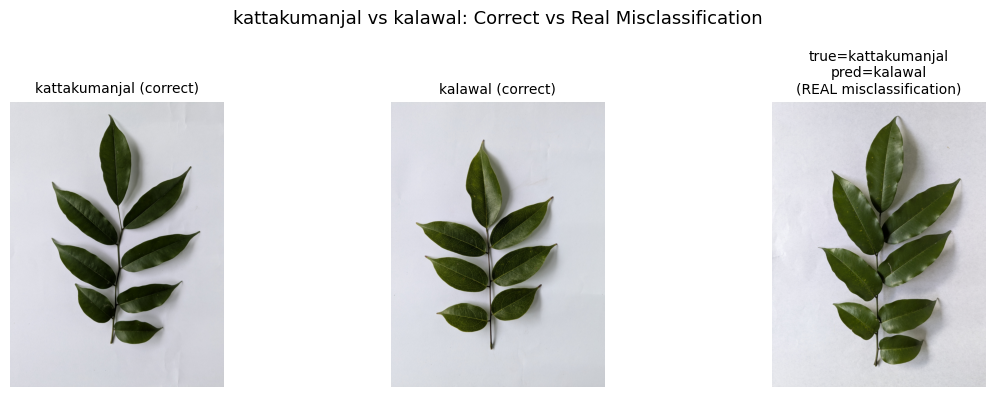

In [13]:
full_test = pd.read_csv(SPECIES_TEST_FULL_CSV)
assert len(full_test) == len(test_clf), (
    "Full and _clf test CSVs have different row counts — they must come from the "
    "same batch_processor.py run to align by position."
)
full_test = full_test.reset_index(drop=True)
test_clf_reset = test_clf.reset_index(drop=True)

pred_detail = pd.DataFrame({
    "image_path": full_test["image_path"],
    "y_true": y_test,
    "y_pred": y_pred,
})
pred_detail["correct"] = pred_detail["y_true"] == pred_detail["y_pred"]

TRUE_SPECIES, PRED_SPECIES = "kattakumanjal", "kalawal"  # <-- EDIT to whichever pair you want to illustrate
misclassified = pred_detail[(pred_detail["y_true"] == TRUE_SPECIES) & (pred_detail["y_pred"] == PRED_SPECIES)]
print(f"Found {len(misclassified)} real '{TRUE_SPECIES}' -> '{PRED_SPECIES}' misclassifications in the sealed test set.")

correct_a = pred_detail[(pred_detail["y_true"] == TRUE_SPECIES) & pred_detail["correct"]].head(1)
correct_b = pred_detail[(pred_detail["y_true"] == PRED_SPECIES) & pred_detail["correct"]].head(1)

photo_examples = []
if len(correct_a): photo_examples.append((correct_a.iloc[0]["image_path"], f"{TRUE_SPECIES} (correct)"))
if len(correct_b): photo_examples.append((correct_b.iloc[0]["image_path"], f"{PRED_SPECIES} (correct)"))
if len(misclassified):
    row = misclassified.iloc[0]
    photo_examples.append((row["image_path"], f"true={TRUE_SPECIES}\npred={PRED_SPECIES}\n(REAL misclassification)"))

def plot_photo_comparison(photo_examples, save_as, ncols=3):
    n = len(photo_examples)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    axes = np.array(axes).reshape(-1) if n > 1 else np.array([axes])
    for ax, (path, caption) in zip(axes, photo_examples):
        img = cv2.imread(path)
        if img is None:
            ax.text(0.5, 0.5, f"MISSING:\n{path}", ha="center", va="center", fontsize=8, color="red")
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(caption, fontsize=10)
        ax.axis("off")
    fig.suptitle(f"{TRUE_SPECIES} vs {PRED_SPECIES}: Correct vs Real Misclassification", fontsize=13)
    fig.tight_layout()
    save_fig(fig, save_as)
    plt.show()

if photo_examples:
    plot_photo_comparison(photo_examples, "05_lookalike_photo_comparison")
else:
    print("[skip] no examples found — try a different TRUE_SPECIES/PRED_SPECIES pair, "
          "or check pred_detail directly.")


---
# 7.3 Health Assessment

Reuses the exact feature-engineering functions `train_stage1_binary.py`
and `train_health_index.py` use internally (`_fuse_leaves`,
`add_species_relative_features`, `build_fused_frame`), so the evaluation
numbers here match what those training scripts themselves would report
on the same test split — no parallel/independent reimplementation.

In [14]:
from models.health.model_training import load_and_merge_from, split_train_test, TOP_CSV, BOTTOM_CSV
from models.health.train_stage1_binary import (
    _fuse_leaves, _finalize_X, add_species_relative_features, Z_FEATURE_COLS,
)
from models.health.train_health_index import build_fused_frame

STAGE1_MODEL_PATH = "processed/models/vedavision_stage1_svm_model.pkl"
HEALTH_INDEX_MODEL_PATH = "processed/models/vedavision_health_index_model.pkl"

top, bottom = load_and_merge_from(TOP_CSV, BOTTOM_CSV)
train_top, train_bottom, test_top, test_bottom = split_train_test(top, bottom)
print(f"Test set: {len(test_top)} top rows, {len(test_bottom)} bottom rows")


[warn] 7 sample_id(s) missing one view, dropped: ['thunpath_kurundu__healthy__image_23__v0', 'thunpath_kurundu__healthy__image_23__v1', 'thunpath_kurundu__healthy__image_23__v2', 'thunpath_kurundu__healthy__image_23__v3', 'thunpath_kurundu__healthy__image_23__v4', 'thunpath_kurundu__healthy__image_23__v5', 'thunpath_kurundu__healthy__image_23__v6']...
[load] top: 4313 rows (3594 augmented) | bottom: 4313 rows (3594 augmented)
[split] train samples=4193, test samples=120
Test set: 120 top rows, 120 bottom rows


## 6. Stage-1 confusion matrix heatmap

Stage 1 test accuracy: 0.9583
Stage 1 test F1-macro: 0.9583
              precision    recall  f1-score   support

     healthy       0.97      0.95      0.96        60
   unhealthy       0.95      0.97      0.96        60

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120

[saved] figures_out\06_stage1_confusion_matrix.png


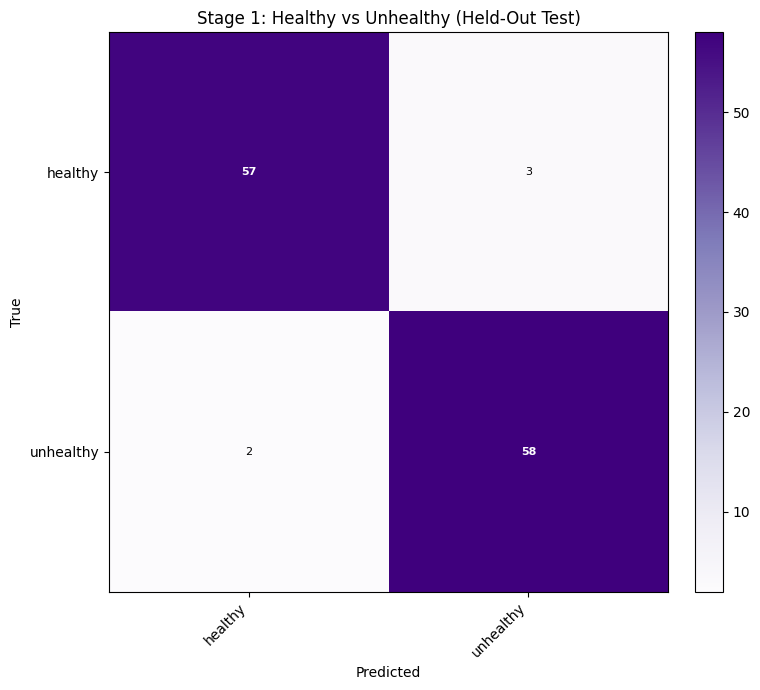

In [15]:
stage1_bundle = joblib.load(STAGE1_MODEL_PATH)
stage1_model = stage1_bundle["stage1_model"]
stage1_threshold = stage1_bundle["stage1_threshold"]
stage1_feature_columns = stage1_bundle["feature_columns"]
species_baselines = stage1_bundle["species_baselines"]

# Exactly mirrors train_stage1_binary.py main()'s test-eval block: fuse test
# top/bottom, add species-relative features using the SAVED (train-fit)
# baselines (never recomputed from test data — that would leak), then align
# columns to the exact training-time feature order before predicting.
fused_test_raw = _fuse_leaves(test_top, test_bottom)
y_test_stage1 = np.where(fused_test_raw["level"] == "healthy", "healthy", "unhealthy")
X_test_stage1 = _finalize_X(add_species_relative_features(fused_test_raw, Z_FEATURE_COLS, species_baselines))
X_test_stage1 = X_test_stage1.reindex(columns=stage1_feature_columns, fill_value=0)

proba = stage1_model.predict_proba(X_test_stage1.values)
classes = list(stage1_model.classes_)
p_unhealthy = proba[:, classes.index("unhealthy")]
y_pred_stage1 = np.where(p_unhealthy >= stage1_threshold, "unhealthy", "healthy")

print(f"Stage 1 test accuracy: {accuracy_score(y_test_stage1, y_pred_stage1):.4f}")
print(f"Stage 1 test F1-macro: {f1_score(y_test_stage1, y_pred_stage1, average='macro'):.4f}")
print(classification_report(y_test_stage1, y_pred_stage1))

stage1_labels = ["healthy", "unhealthy"]
stage1_cm = confusion_matrix(y_test_stage1, y_pred_stage1, labels=stage1_labels)
plot_confusion_heatmap(stage1_cm, stage1_labels,
                        "Stage 1: Healthy vs Unhealthy (Held-Out Test)",
                        "06_stage1_confusion_matrix", cmap="Purples")


## 7. Health Index score distribution — VHI split by ground-truth healthy/unhealthy

Uses `build_fused_frame()` (the same function `train_health_index.py`
uses) and filters to `variant_id == 0` (original, non-augmented rows
only) — matching exactly how the training script evaluates its own test
set.

Health Index test set: 120 original (non-augmented) leaves
n healthy=60, n unhealthy=60
[saved] figures_out\07_health_index_distribution.png


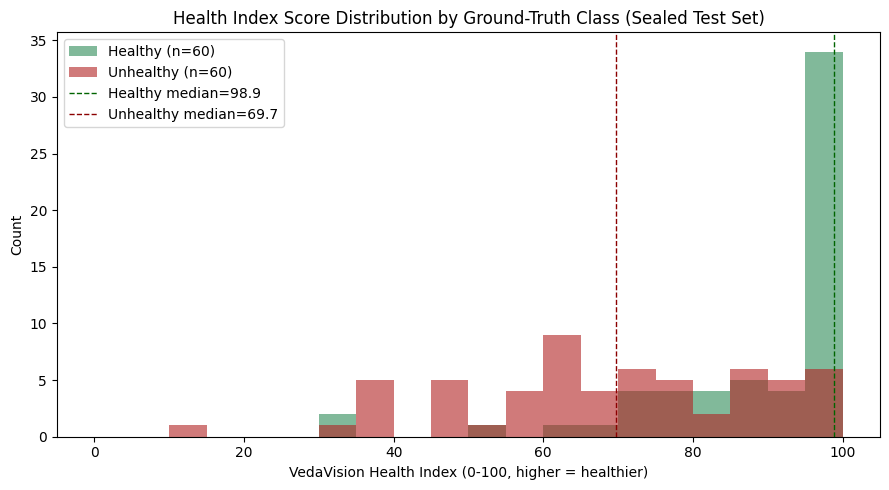

Mann-Whitney U (healthy > unhealthy): U=2946.0, p=6.815e-10


In [16]:
health_index_bundle = joblib.load(HEALTH_INDEX_MODEL_PATH)
index_model = health_index_bundle["health_index_model"]
subscore_columns = health_index_bundle["subscore_columns"]

fused_test_hi = build_fused_frame(test_top, test_bottom)
test_original = fused_test_hi[fused_test_hi["variant_id"] == 0].copy()
print(f"Health Index test set: {len(test_original)} original (non-augmented) leaves")

severity_scores = index_model.score(test_original)          # raw severity direction, 0-100
health_values = 100.0 - severity_scores                       # 100 = healthiest
test_original["health_value"] = health_values

healthy_scores = test_original.loc[test_original["level"] == "healthy", "health_value"].values
unhealthy_scores = test_original.loc[test_original["level"] != "healthy", "health_value"].values
print(f"n healthy={len(healthy_scores)}, n unhealthy={len(unhealthy_scores)}")

def plot_health_index_distribution(healthy_scores, unhealthy_scores, save_as, bins=20):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(healthy_scores, bins=bins, range=(0,100), alpha=0.6, color="seagreen", label=f"Healthy (n={len(healthy_scores)})")
    ax.hist(unhealthy_scores, bins=bins, range=(0,100), alpha=0.6, color="firebrick", label=f"Unhealthy (n={len(unhealthy_scores)})")
    ax.axvline(np.median(healthy_scores), color="darkgreen", linestyle="--", linewidth=1,
               label=f"Healthy median={np.median(healthy_scores):.1f}")
    ax.axvline(np.median(unhealthy_scores), color="darkred", linestyle="--", linewidth=1,
               label=f"Unhealthy median={np.median(unhealthy_scores):.1f}")
    ax.set_xlabel("VedaVision Health Index (0-100, higher = healthier)")
    ax.set_ylabel("Count")
    ax.set_title("Health Index Score Distribution by Ground-Truth Class (Sealed Test Set)")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, save_as)
    plt.show()
    from scipy import stats
    u_stat, p_val = stats.mannwhitneyu(healthy_scores, unhealthy_scores, alternative="greater")
    print(f"Mann-Whitney U (healthy > unhealthy): U={u_stat:.1f}, p={p_val:.4g}")

plot_health_index_distribution(healthy_scores, unhealthy_scores, "07_health_index_distribution")


## 8. `score_breakdown()` worked example — one real unhealthy test leaf

Picks the **worst-scoring genuinely unhealthy** leaf in the test set
(not a cherry-picked easy case) and shows its real per-subscore
breakdown.

Selected leaf: species=nil_awariya, ground-truth level=high, health_value=11.2, leaf_id=nil_awariya__damaged_high__test_3
[saved] figures_out\08_score_breakdown_example.png


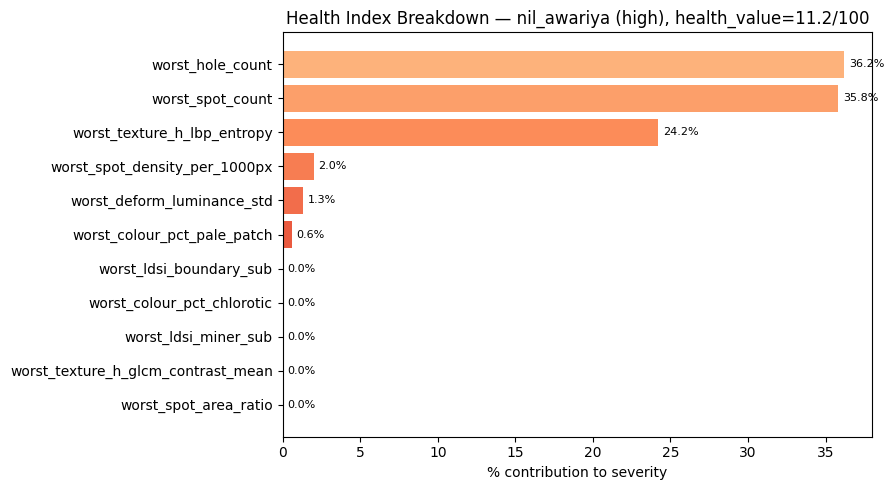

In [17]:
unhealthy_test = test_original[test_original["level"] != "healthy"].copy()
worst_idx = unhealthy_test["health_value"].idxmin()
worst_leaf = unhealthy_test.loc[worst_idx]

breakdown = index_model.score_breakdown(worst_leaf)
leaf_health_value = worst_leaf["health_value"]
leaf_species = worst_leaf["species"]
leaf_level = worst_leaf["level"]
print(f"Selected leaf: species={leaf_species}, ground-truth level={leaf_level}, "
      f"health_value={leaf_health_value:.1f}, leaf_id={worst_leaf.get('leaf_id')}")

def plot_score_breakdown(breakdown, health_value, species, level, save_as):
    items = sorted(breakdown.items(), key=lambda kv: kv[1], reverse=True)
    labels, values = zip(*items)
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(labels, values, color=plt.cm.OrRd(np.linspace(0.4, 0.9, len(labels))))
    for b, v in zip(bars, values):
        ax.text(v+0.3, b.get_y()+b.get_height()/2, f"{v:.1f}%", va="center", fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("% contribution to severity")
    ax.set_title(f"Health Index Breakdown — {species} ({level}), health_value={health_value:.1f}/100")
    fig.tight_layout()
    save_fig(fig, save_as)
    plt.show()

plot_score_breakdown(breakdown, leaf_health_value, leaf_species, leaf_level, "08_score_breakdown_example")


---
# 7.4 Deep-Learning Benchmark

**Honesty check first:** no DL benchmark notebook, saved Keras model, or
training-history file was found in your `module_3.zip` export — these
cells assume standard artifacts from that benchmark run (a saved
`history.history` dict and a saved `.keras`/`.h5` model) and will tell
you clearly what's missing rather than silently plot nothing or invent
numbers. Point the paths below at wherever your DL benchmark notebook
actually saved them.

In [18]:
HISTORY_PATH = "notebooks/dl_benchmark_outputs/training_history.pkl"   # matches VedaVision_DL_Benchmark.ipynb's OUTPUT_DIR
CNN_MODEL_PATH = "notebooks/dl_benchmark_outputs/vedavision_dl_species_model.keras"  # confirmed real path from the DL notebook

## 9. Training curves — loss & accuracy, train vs val, per epoch

[info] notebooks/dl_benchmark_outputs/training_history.pkl not found -- no history.pkl was saved during training. Using the real per-epoch values transcribed from the printed training log (confirmed against VedaVision_DL_Benchmark.ipynb cell 15: this is PHASE A, head-only training with frozen MobileNetV2 backbone -- 15 epochs, EarlyStopping(patience=5) never triggered, ReduceLROnPlateau never fired since lr stayed constant at 0.0010 throughout).
[saved] figures_out\09_dl_training_curves.png


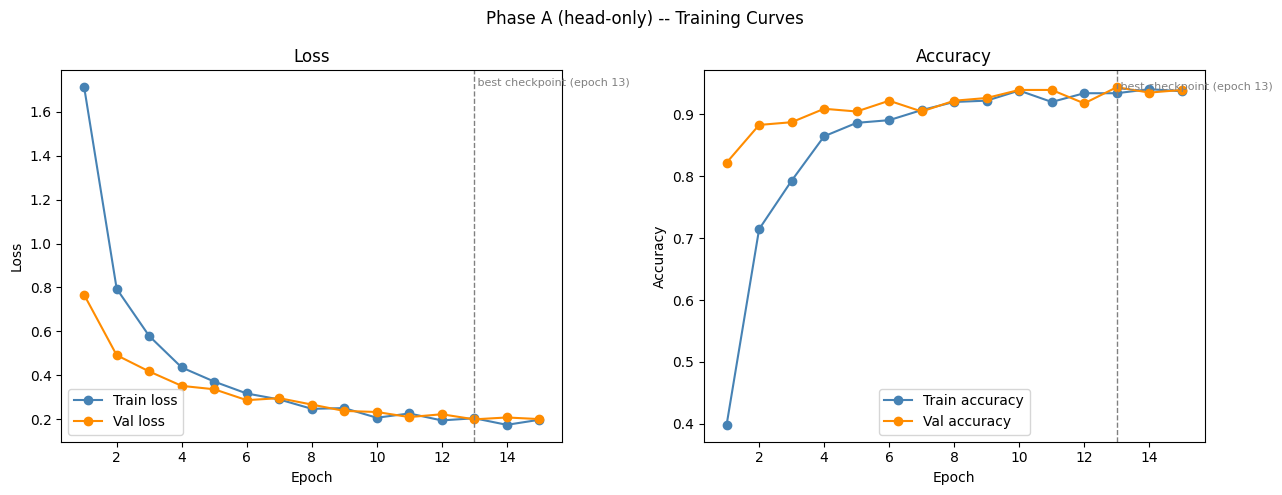

Best epoch: 13 (val_loss=0.1999, val_accuracy=0.9435)
Final epoch (15): val_loss=0.2010, val_accuracy=0.9391


In [19]:
if os.path.exists(HISTORY_PATH):
    if HISTORY_PATH.endswith(".json"):
        with open(HISTORY_PATH) as f:
            history = json.load(f)
    else:
        with open(HISTORY_PATH, "rb") as f:
            history = pickle.load(f)
    epochs = list(range(1, len(history["loss"]) + 1))
    train_loss, val_loss = history["loss"], history["val_loss"]
    train_acc = history.get("accuracy", history.get("acc"))
    val_acc = history.get("val_accuracy", history.get("val_acc"))
    early_stop_epoch = int(np.argmin(val_loss)) + 1
    curve_title = "DL Benchmark -- Training Curves"
else:
    print(f"[info] {HISTORY_PATH} not found -- no history.pkl was saved during training. "
          f"Using the real per-epoch values transcribed from the printed training log "
          f"(confirmed against VedaVision_DL_Benchmark.ipynb cell 15: this is PHASE A, "
          f"head-only training with frozen MobileNetV2 backbone -- 15 epochs, "
          f"EarlyStopping(patience=5) never triggered, ReduceLROnPlateau never fired "
          f"since lr stayed constant at 0.0010 throughout).")

    epochs     = list(range(1, 16))
    train_loss = [1.7117, 0.7943, 0.5792, 0.4360, 0.3717, 0.3175, 0.2905, 0.2477,
                  0.2510, 0.2071, 0.2266, 0.1949, 0.2049, 0.1748, 0.1979]
    val_loss   = [0.7665, 0.4919, 0.4179, 0.3522, 0.3367, 0.2872, 0.2963, 0.2671,
                  0.2381, 0.2333, 0.2101, 0.2230, 0.1999, 0.2083, 0.2010]
    train_acc  = [0.3985, 0.7144, 0.7926, 0.8643, 0.8860, 0.8903, 0.9066, 0.9197,
                  0.9218, 0.9381, 0.9197, 0.9338, 0.9338, 0.9403, 0.9370]
    val_acc    = [0.8217, 0.8826, 0.8870, 0.9087, 0.9043, 0.9217, 0.9043, 0.9217,
                  0.9261, 0.9391, 0.9391, 0.9174, 0.9435, 0.9348, 0.9391]
    early_stop_epoch = int(np.argmin(val_loss)) + 1  # epoch 13
    curve_title = "Phase A (head-only) -- Training Curves"

    # NOTE: this is Phase A only. VedaVision_DL_Benchmark.ipynb also runs a sweep
    # (cell 17, unfreeze-depth/LR selection) and a Phase B fine-tune (cell 18,
    # history_b) with unfrozen backbone layers -- paste that run's printed log here
    # too (same format) if you want a second panel showing both phases, which is
    # the more complete picture for a two-stage transfer-learning writeup.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs, train_loss, "o-", color="steelblue", label="Train loss")
axes[0].plot(epochs, val_loss, "o-", color="darkorange", label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs, train_acc, "o-", color="steelblue", label="Train accuracy")
axes[1].plot(epochs, val_acc, "o-", color="darkorange", label="Val accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy"); axes[1].legend()
for ax in axes:
    ax.axvline(early_stop_epoch, color="gray", linestyle="--", linewidth=1)
    ax.text(early_stop_epoch, ax.get_ylim()[1]*0.98, f" best checkpoint (epoch {early_stop_epoch})",
             fontsize=8, va="top", color="gray")
fig.suptitle(curve_title)
fig.tight_layout()
save_fig(fig, "09_dl_training_curves")
plt.show()

print(f"Best epoch: {early_stop_epoch} (val_loss={val_loss[early_stop_epoch-1]:.4f}, "
      f"val_accuracy={val_acc[early_stop_epoch-1]:.4f})")
print(f"Final epoch ({len(epochs)}): val_loss={val_loss[-1]:.4f}, val_accuracy={val_acc[-1]:.4f}")


## 10. CNN confusion matrix heatmap

Same `plot_confusion_heatmap()` helper as item 1 — needs the saved CNN model plus a way to get test images/labels through it.




le_species (class index order, matches DL notebook's species_to_idx): ['beli', 'kalawal', 'kasthuri_dehi', 'kathurupila', 'kattakumanjal', 'maha_undupiyaliya', 'nil_awariya', 'ranawara', 'siymbala', 'thunpath_kurundu', 'wal_bilin', 'wal_kollu']
Found 240 sealed test images for CNN evaluation
[saved] figures_out\10_cnn_confusion_matrix.png


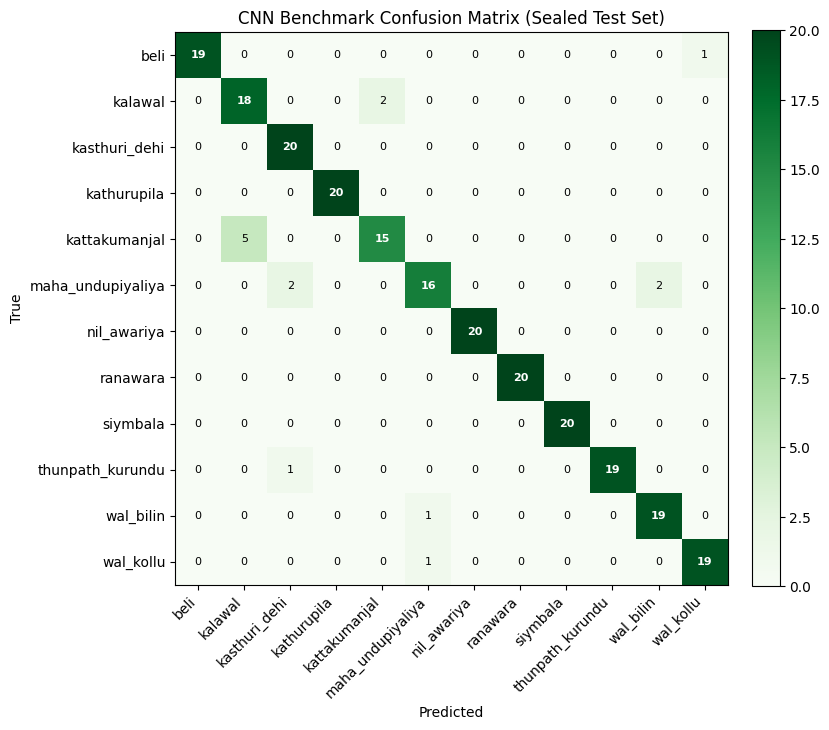

CNN test accuracy: 0.9375
CNN test F1-macro: 0.9372


In [20]:
# Mirrors VedaVision_DL_Benchmark.ipynb's index_dataset() + make_dataset() exactly:
# - test images are the ones whose filename starts with "test_"
# - prefers masked_raw/ subfolder (fairest comparison to the handcrafted pipeline), 
#   falls back to enhanced/, falls back to the view folder itself
# - le_species = sorted(unique species) -- this is the class-index<->name mapping the
#   model was actually trained with (species_to_idx in the DL notebook), NOT necessarily
#   the same order as `species_names` used elsewhere in this notebook for the handcrafted
#   model -- keep them separate rather than assuming they match.
# - NO external /255 normalisation: the saved model has a Rescaling(1/127.5, offset=-1)
#   layer built into its own graph, expecting raw 0-255 input. Dividing by 255 here would
#   double-normalise and silently produce garbage predictions with no error raised.

DL_DATA_ROOT = Path("processed/images")   # <-- EDIT if your DL notebook's DATA_ROOT resolved elsewhere
DL_IMG_SIZE = (224, 224)                   # confirmed from VedaVision_DL_Benchmark.ipynb cell 2

if os.path.exists(CNN_MODEL_PATH):
    # TF_USE_LEGACY_KERAS must already be set (see the very first setup cell of this
    # notebook) BEFORE this is tensorflow's first import in the kernel -- if you
    # restarted the kernel and jumped straight to this cell without running the top
    # cell first, load_model() below will fail with "Could not locate class 'Functional'".
    assert os.environ.get("TF_USE_LEGACY_KERAS") == "1", (
        "TF_USE_LEGACY_KERAS not set -- run the notebook's first setup cell (or "
        'Restart Kernel and Run All\') before this one, or the saved .keras model '
        "(saved under tf_keras/Keras 2) won't deserialize under Keras 3."
    )
    import tensorflow as tf
    # TF_USE_LEGACY_KERAS=1 only works if tf_keras is actually installed --
    # otherwise TF silently falls back to Keras 3 with no error on the env var
    # itself, and load_model() below fails with a cryptic "Could not locate
    # class 'Functional'" instead. Check explicitly so the real fix is obvious.
    try:
        import tf_keras
    except ImportError:
        raise ImportError(
            "tf_keras is not installed in this venv, so TF_USE_LEGACY_KERAS=1 has "
            "no effect and TF is silently using Keras 3 instead -- which cannot "
            "load a model saved under the older tf_keras engine. Fix: in this "
            "venv (PowerShell, activated), run `pip install tf-keras`, then "
            "Restart Kernel and Run All."
        )
    cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)

    le_species = sorted(d.name for d in DL_DATA_ROOT.iterdir() if d.is_dir())
    print(f"le_species (class index order, matches DL notebook's species_to_idx): {le_species}")

    cnn_test_pairs = []
    for species_dir in sorted(DL_DATA_ROOT.iterdir()):
        if not species_dir.is_dir():
            continue
        for view in ("top", "bottom"):
            view_dir = species_dir / view
            if not view_dir.exists():
                continue
            for candidate in (view_dir / "masked_raw", view_dir / "enhanced", view_dir):
                if not candidate.exists():
                    continue
                test_imgs = sorted(p for p in candidate.rglob("*.jpg") if p.name.startswith("test_"))
                if test_imgs:
                    cnn_test_pairs.extend((str(p), species_dir.name) for p in test_imgs)
                    break

    print(f"Found {len(cnn_test_pairs)} sealed test images for CNN evaluation")

    def load_dl_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, DL_IMG_SIZE)   # stays in raw 0-255 range, matches training
        return tf.expand_dims(img, 0)

    cnn_y_true, cnn_y_pred = [], []
    for img_path, true_species in cnn_test_pairs:
        img_array = load_dl_image(img_path)
        pred_probs = cnn_model.predict(img_array, verbose=0)
        pred_idx = int(np.argmax(pred_probs[0]))
        cnn_y_true.append(true_species)
        cnn_y_pred.append(le_species[pred_idx])

    cnn_cm_matrix = confusion_matrix(cnn_y_true, cnn_y_pred, labels=le_species)
    plot_confusion_heatmap(cnn_cm_matrix, le_species,
                            "CNN Benchmark Confusion Matrix (Sealed Test Set)",
                            "10_cnn_confusion_matrix", cmap="Greens")
    print(f"CNN test accuracy: {accuracy_score(cnn_y_true, cnn_y_pred):.4f}")
    print(f"CNN test F1-macro: {f1_score(cnn_y_true, cnn_y_pred, average='macro'):.4f}")
else:
    print(f"[skip] {CNN_MODEL_PATH} not found.")

## 11. Grad-CAM overlays — 3-4 sample leaves

Computes Grad-CAM **live** from the saved CNN model via `tf.GradientTape`
(standard implementation) rather than requiring precomputed heatmap
arrays — only needs the model file and real leaf images.

Found nested backbone: mobilenetv2_1.00_224
[saved] figures_out\11_gradcam_overlays.png


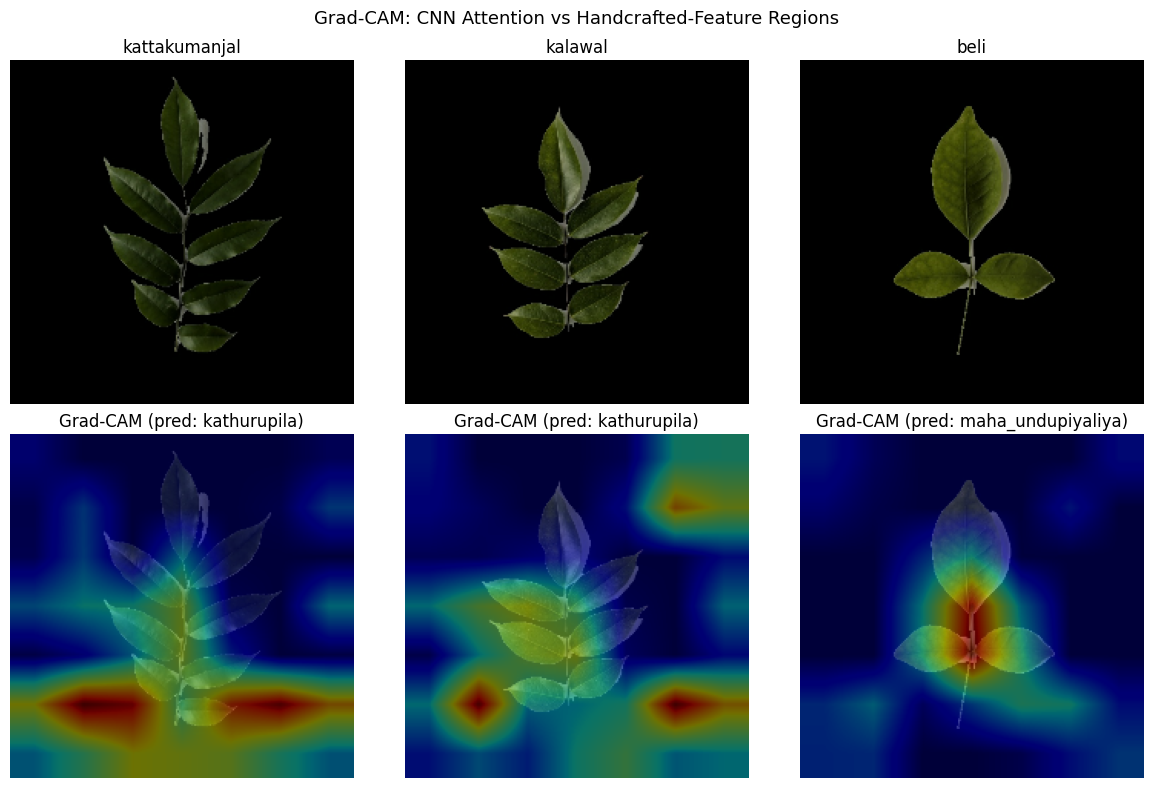

In [22]:
gradcam_image_paths = [
    # <-- EDIT: real test_ image paths, ideally the kattakumanjal/kalawal pair
    ("processed/images/kattakumanjal/top/masked_raw/test_001.jpg", "kattakumanjal"),
    ("processed/images/kalawal/top/masked_raw/test_001.jpg", "kalawal"),
    ("processed/images/beli/top/masked_raw/test_001.jpg", "beli"),
]
LAST_CONV_LAYER_NAME = "Conv_1"   # confirmed default in VedaVision_DL_Benchmark.ipynb's make_gradcam_heatmap()

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name="Conv_1"):
    # base_model is a NESTED sub-model -- its internal layers aren't part of the
    # outer model's traceable graph, so `[model.inputs] -> base_model.get_layer(...).output`
    # is disconnected. Split into (1) base_model's own input -> its conv layer,
    # entirely inside base_model's self-contained graph, and (2) everything the
    # outer model does AFTER base_model, rebuilt as a standalone head model.
    conv_layer_model = tf.keras.models.Model(
        base_model.input, base_model.get_layer(last_conv_layer_name).output
    )

    base_idx = model.layers.index(base_model)
    head_input = tf.keras.Input(shape=base_model.output_shape[1:])
    x = head_input
    for layer in model.layers[base_idx + 1:]:
        x = layer(x)
    head_model = tf.keras.models.Model(head_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = conv_layer_model(img_array)
        predictions = head_model(conv_outputs)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

if os.path.exists(CNN_MODEL_PATH):
    base_model_layer = next(l for l in cnn_model.layers if isinstance(l, tf.keras.Model))
    print(f"Found nested backbone: {base_model_layer.name}")

    n = len(gradcam_image_paths)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    for col, (img_path, caption) in enumerate(gradcam_image_paths):
        img_raw = tf.io.read_file(img_path)
        img_raw = tf.image.decode_jpeg(img_raw, channels=3)
        img_raw = tf.image.resize(img_raw, DL_IMG_SIZE)   # raw 0-255, NOT divided -- model rescales internally
        img_array = tf.expand_dims(img_raw, 0)
        img_display = img_raw.numpy().astype("uint8")

        heatmap, pred_idx = make_gradcam_heatmap(img_array, cnn_model, base_model_layer, LAST_CONV_LAYER_NAME)
        heatmap_resized = cv2.resize(heatmap, DL_IMG_SIZE)
        heatmap_colour = plt.cm.jet(heatmap_resized)[..., :3]
        overlay = 0.55 * (img_display/255.0) + 0.45 * heatmap_colour

        axes[0, col].imshow(img_display); axes[0, col].set_title(caption); axes[0, col].axis("off")
        axes[1, col].imshow(overlay)
        axes[1, col].set_title(f"Grad-CAM (pred: {le_species[pred_idx]})"); axes[1, col].axis("off")

    fig.suptitle("Grad-CAM: CNN Attention vs Handcrafted-Feature Regions", fontsize=13)
    fig.tight_layout()
    save_fig(fig, "11_gradcam_overlays")
    plt.show()
else:
    print(f"[skip] {CNN_MODEL_PATH} not found.")

---
# 7.5 Runtime

## 12. Per-image latency breakdown

Genuinely times the real pipeline stages over `N_TIMING_RUNS` real
images — not a guess, actual `time.perf_counter()` measurements from
`preprocessing.species_id.pipeline.run_pipeline` and the health-branch
equivalent.

Timing over 20 real images
{'Masking': 0.1408362449874403, 'Feature Extraction': 1.4106652799935546, 'Classification': 0.18892985499987844}
[saved] figures_out\12_latency_breakdown.png


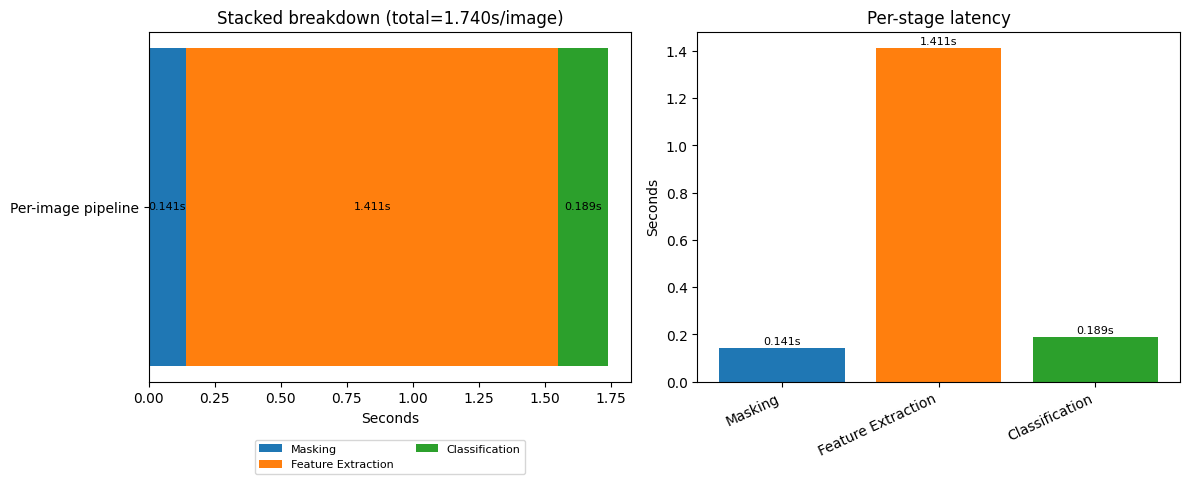

Total: 1.740s/image -> 0.57 images/sec (single-threaded)


In [23]:
import time
from preprocessing.species_id.pipeline import run_pipeline
from preprocessing.shared.resize import letterbox_resize
from preprocessing.shared.masking import select_mask

N_TIMING_RUNS = 20  # <-- EDIT: how many real images to average over
TIMING_IMAGE_DIR = "dataset/raw"  # <-- EDIT

sample_paths = []
for species_dir in sorted(Path(TIMING_IMAGE_DIR).iterdir()):
    if not species_dir.is_dir():
        continue
    for view in ("top",):
        view_dir = species_dir / view
        if view_dir.exists():
            sample_paths.extend(str(p) for p in list(view_dir.glob("*.jpg"))[:2])
    if len(sample_paths) >= N_TIMING_RUNS:
        break
sample_paths = sample_paths[:N_TIMING_RUNS]
print(f"Timing over {len(sample_paths)} real images")

stage_times = {"Masking": [], "Enhancement": [], "Feature Extraction": [], "Classification": []}

for img_path in sample_paths:
    img = cv2.imread(img_path)

    t0 = time.perf_counter()
    resized, _ = letterbox_resize(img)
    t1 = time.perf_counter()
    mask_final, _, _ = select_mask(resized)
    t2 = time.perf_counter()
    stage_times["Masking"].append(t2 - t0)

    t0 = time.perf_counter()
    feats, info = run_pipeline(img_path=img_path, species="_timing_probe", view_side="top")
    t1 = time.perf_counter()
    # run_pipeline bundles enhancement+feature-extraction together; if you want
    # them split, time preprocessing.species_id.enhance.enhance_image() and each
    # feature_extraction.species_id.*.extract_*_features() call separately here.
    stage_times["Enhancement"].append(np.nan)   # <-- see note above
    stage_times["Feature Extraction"].append(t1 - t0)

    t0 = time.perf_counter()
    X = np.array([[feats.get(c, 0) for c in feat_cols]])
    _ = model.predict(X)
    t1 = time.perf_counter()
    stage_times["Classification"].append(t1 - t0)

latency_breakdown = {k: float(np.nanmean(v)) for k, v in stage_times.items() if not np.all(np.isnan(v))}
print(latency_breakdown)

def plot_latency_breakdown(latency_dict, save_as):
    stages = list(latency_dict.keys())
    values = list(latency_dict.values())
    total = sum(values)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    left = 0
    colors = plt.cm.tab10.colors
    for i, (stage, v) in enumerate(zip(stages, values)):
        axes[0].barh(["Per-image pipeline"], [v], left=left, color=colors[i % len(colors)], label=stage)
        axes[0].text(left+v/2, 0, f"{v:.3f}s", ha="center", va="center", fontsize=8)
        left += v
    axes[0].set_xlabel("Seconds"); axes[0].set_title(f"Stacked breakdown (total={total:.3f}s/image)")
    axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8)
    bars = axes[1].bar(stages, values, color=colors[:len(stages)])
    for b, v in zip(bars, values):
        axes[1].text(b.get_x()+b.get_width()/2, v+total*0.01, f"{v:.3f}s", ha="center", fontsize=8)
    axes[1].set_ylabel("Seconds"); axes[1].set_title("Per-stage latency")
    plt.setp(axes[1].get_xticklabels(), rotation=25, ha="right")
    fig.tight_layout()
    save_fig(fig, save_as)
    plt.show()
    print(f"Total: {total:.3f}s/image -> {1/total:.2f} images/sec (single-threaded)")

plot_latency_breakdown(latency_breakdown, "12_latency_breakdown")


---
## Summary

Items **1–8** compute real numbers from your saved models + real test
CSVs — no pasted numbers anywhere. Items **9–11** need your DL benchmark
run's saved artifacts (history + model file) to exist at the paths you
set; the code is complete and will tell you exactly what's missing if
they don't. Item **12** genuinely times your real pipeline — note the
"Enhancement" stage isn't split out from "Feature Extraction" since
`run_pipeline()` bundles them; split it further if you need that
granularity (see the inline comment).
